# Sarcopenia Dataset Analysis: Male Participants - Total Activity Count Prediction using kNN

## Overview

This notebook presents an analysis of sarcopenia (age-related loss of muscle mass and function) focusing on **male participants**. The analysis uses k-Nearest Neighbors (kNN) models to predict **total activity count** as a proxy for physical activity and muscle function.

### Dataset Information

- **Focus**: Male participants (gender == 1)
- **Objective**: Identify relevant features for conditional mean and variance in total activity count prediction
- **Target variable**: Total Activity Count (TAC) - a measure of physical activity derived from accelerometer data
- **Preprocessing**: Unnecessary variables and missing data have been removed

---

## Methodology

### 1. Data Preprocessing

**Filtering**:
- Only male participants selected (gender == 1)
- Focus on relationship between age, BMI, and physical activity levels

**Independent variables (X)**:
- **age**: Age (years)
- **bmi**: Body Mass Index

**Dependent variable (Y)**:
- **tac.x**: Total Activity Count - cumulative measure of physical activity
  - Higher values indicate greater physical activity
  - Lower values may indicate sarcopenia or reduced mobility

**Note**: This is a simplified model using only age and BMI to examine their relationship with physical activity in aging males.

### 2. kNN Model Configuration

Dual modeling approach:

1. **Conditional mean model**: Predicts expected total activity count
2. **Conditional variance model**: Predicts variability in activity levels

**Hyperparameters**:
- Search grid for k: [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
- Separate grids for mean (`grida`) and variance (`gridv`)
- Automatic feature selection with statistical significance testing

### 3. Prediction Interval Computation

**Quantile-based intervals**:
- Compute standardized residuals: ||(y - mean) / sqrt(variance)||
- Calculate quantiles of residuals
- Construct prediction intervals: mean ± quantile × sqrt(variance)

**Purpose**: Identify normal ranges of activity and detect outliers (potential sarcopenia cases)

### 4. Visualization Strategy

Two main visualizations:

1. **Conditional Mean (3D)**: Age vs. BMI vs. Expected Activity Count
2. **Conditional Standard Deviation (3D)**: Age vs. BMI vs. Activity Variability

**Color mapping**: Viridis colormap for better gradient perception

---

## Expected Results

1. **Age effect**: Negative correlation between age and activity count (sarcopenia progression)
2. **BMI effect**: Examine how body composition affects activity levels
3. **Variance patterns**: Identify which age/BMI groups show higher activity variability
4. **Clinical insights**: Understand normal activity ranges for different age/BMI profiles

---

## Clinical Relevance

**Sarcopenia** is characterized by:
- Progressive loss of skeletal muscle mass
- Decreased muscle strength and function
- Reduced physical activity levels

This analysis helps identify:
- Expected activity levels for different age groups
- Risk profiles based on age and BMI
- Individuals with abnormally low activity (potential sarcopenia)

---

## Technical Notes

- **Reproducibility**: Fixed seeds for numpy and random
- **Data type**: float32 for computational efficiency
- **Sample size**: Male participants only
- **Grid resolution**: Fine-grained (step=0.1) for smooth visualizations

In [1]:
# Import required libraries

import sys
sys.path.append("../..")  # Add path to import knnvs module

# Standard libraries
import math
import random
import logging

# Data analysis libraries
import numpy as np
import pandas as pd

# Machine learning libraries
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split

# knnvs module (custom kNN implementation)
from knnvs import KnnBag, KnnVar, initialize_knn, roc

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure visualization parameters
mpl.rcParams['axes.labelsize'] = 9  # Axis label size

## Data Loading and Preparation

In this section we load the sarcopenia dataset and **filter for male participants**.

**Selected variables**:
- **Independent (X)**: age, BMI
- **Dependent (Y)**: total activity count (tac.x)

**Important**: This is a parsimonious model focusing on the two most fundamental predictors of physical activity in aging males.

In [2]:
# Set seeds for reproducibility
random.seed(1)
np.random.seed(1)

# Grids for hyperparameter k search
# grida: k values for conditional mean model
# gridv: k values for conditional variance model
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

# Load dataset
df = pd.read_csv('data/sarcopenia.csv')

# Filter for MALE participants only (gender == 1)
df = df.loc[df['gender'] == 1]

# Define dependent and independent variables
out = 'tac.x'  # Target variable: Total Activity Count
inp = np.array([
    "age",  # Age (years)
    "bmi"   # Body Mass Index
])

# Convert to numpy arrays with float32 type
y = df[out].to_numpy().astype('float32')  # Total activity count
x = df[inp].to_numpy().astype('float32')  # Independent variables

print(f'Total male participants: {len(y)}')
print(f'Age range: {x[:, 0].min():.1f} - {x[:, 0].max():.1f} years')
print(f'BMI range: {x[:, 1].min():.1f} - {x[:, 1].max():.1f}')
print(f'Activity count range: {y.min():.1f} - {y.max():.1f}')

Total male participants: 1996
Age range: 18.0 - 80.0 years
BMI range: 15.7 - 66.2
Activity count range: 4.9 - 29.1


## kNN Model Initialization and Training

The `initialize_knn` function performs feature selection and model training for male participants.

**Process**:
1. **Feature selection**: Identifies the most relevant variables through statistical tests
2. **Cross-validation**: Finds the optimal k value for each model
3. **Training**: Fits both conditional mean and variance models

**Parameters**:
- `x`, `y`: Input and output data (male participants)
- `grida`, `gridv`: Search grids for k (mean and variance)
- `quantile`: Threshold for feature selection (1 - α = 0.99)

**Returns**:
- `knna0`: kNN model for conditional mean
- `fa0`: Indices of selected features for mean
- `ka0`: Optimal k value for mean
- `pva0`: P-values of features (mean)
- `knnv0`: kNN model for conditional variance
- `fv0`: Indices of selected features for variance
- `kv0`: Optimal k value for variance
- `pvv0`: P-values of features (variance)

**Note**: With only 2 features (age, BMI), it's common that both are retained even if they don't pass strict significance tests.

In [3]:
# Initialize and train kNN models for male participants
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(
    x, y, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn0 = KnnVar(knna0, knnv0)

# Display selected features
print('Selected features for the conditional mean: {}'.format(inp[fa0]))
print('Selected features for the conditional variance: {}'.format(inp[fv0]))
print(f'\nOptimal k value for mean: {ka0}')
print(f'Optimal k value for variance: {kv0}')

No features passed significance test at quantile=0.99. Using all 2 features.
No features passed significance test at quantile=0.99. Using all 2 features.


Selected features for the conditional mean: ['age' 'bmi']
Selected features for the conditional variance: ['age' 'bmi']

Optimal k value for mean: 100
Optimal k value for variance: 100


## Prediction Interval Computation

In this section we compute prediction intervals based on quantiles of standardized residuals.

**Methodology**:
1. Generate predictions for all participants
2. Compute standardized residuals: ||(y - mean) / sqrt(variance)||
3. Calculate quantiles of residuals (0 to 1 in steps of 0.01)
4. Use quantiles to construct prediction intervals

**Applications**:
- Identify outliers (abnormally low activity)
- Define normal ranges for different age/BMI profiles
- Screen for potential sarcopenia cases

In [4]:
# Calculate mean values for all variables
x_mean = np.mean(x, axis=0)

# Generate predictions for all participants
pa = knn0.predict_average(x, k=ka0)      # Predicted mean
pv = knn0.predict_variance(x, k=kv0)     # Predicted variance

# Compute prediction error metrics
msea = skl.mean_squared_error(y, pa)     # Mean squared error for mean predictions
print(f'Mean squared error (mean predictions): {msea:.2f}')

# Compute standardized residuals
# This measures how many standard deviations away each observation is from its predicted mean
residuos = np.abs((y - pa) / np.sqrt(pv))

# Calculate quantiles of residuals
grid = np.arange(0, 1, step=0.01)  # 0th to 100th percentile
q = np.quantile(residuos, grid)

print(f'Median standardized residual: {q[50]:.3f}')
print(f'95th percentile standardized residual: {q[95]:.3f}')
print(f'99th percentile standardized residual: {q[99]:.3f}')

Mean squared error (mean predictions): 5.84
Median standardized residual: 0.659
95th percentile standardized residual: 1.770
99th percentile standardized residual: 2.798


## Constructing Prediction Intervals for Observed Data

Compute prediction intervals (lower and upper bounds) for all observed participants using the median quantile.

**Interval formula**:
- **Lower bound**: predicted_mean - quantile × sqrt(predicted_variance)
- **Upper bound**: predicted_mean + quantile × sqrt(predicted_variance)

**Interpretation**:
- Observations outside these intervals may indicate abnormal activity levels
- Lower bounds are particularly important for sarcopenia screening

In [5]:
# Extract age and BMI for all participants
xk = x[:, 0]  # Age
yk = x[:, 1]  # BMI

# Reconstruct feature matrix
xx = np.concatenate((xk.T, yk.T)).reshape(xk.shape[0], 2)

# Generate predictions for all participants
pka = knn0.predict_average(xx, k=ka0)      # Predicted mean
pkv = knn0.predict_variance(xx, k=kv0)     # Predicted variance

# Construct prediction intervals using 50th percentile (median) quantile
Z1 = pka - pkv * q[50]  # Lower bound
Z2 = pka + pkv * q[50]  # Upper bound

# Store results in DataFrame
dict = {
    "x": xk,           # Age
    "y": yk,           # BMI
    "pka": pka,        # Predicted mean activity
    "pkv": pkv,        # Predicted variance
    "z1": Z1,          # Lower prediction bound
    "z2": Z2           # Upper prediction bound
}
df2 = pd.DataFrame(dict)
df2.to_csv('sarcopenia_gender_1.csv', index=False)

print(f'Saved prediction intervals for {len(df2)} male participants')
print(f'Mean activity count prediction: {pka.mean():.2f} ± {np.sqrt(pkv).mean():.2f}')

Saved prediction intervals for 1996 male participants
Mean activity count prediction: 9.19 ± 2.80


## Generating Predictions on 2D Grid

In this block we generate predictions over a two-dimensional grid to visualize the relationship between age, BMI, and activity count.

**Grid specifications**:
- **Age**: Range from 25 to 75 years (step 0.1)
- **BMI**: Range from 20 to 35 (step 0.1)

**Methodology**:
1. For each (age, BMI) combination:
   - Predict the **conditional mean** of activity count
   - Predict the **conditional variance** of activity count
2. Save results for 3D visualization

**Purpose**: Create smooth surface plots showing how activity changes across age and BMI ranges in males.

In [6]:
# Calculate mean values for all variables
x_mean = np.mean(x, axis=0)

# Define exploration grids for AGE and BMI
agrid = list(np.arange(25, 75, step=0.1))   # Age: 25-75 years with step of 0.1
bgrid = list(np.arange(20, 35, step=0.1))   # BMI: 20-35 with step of 0.1

# Lists to store results
ages = []       # Age values
bmis = []       # BMI values
glucoa = []     # Conditional mean predictions (activity count)
glucov = []     # Conditional variance predictions

# Nested loop to explore all combinations
for a in agrid:
    for b in bgrid:
        # Create feature vector with specific age and BMI
        xi = np.array([a, b]).reshape((1, 2)).astype('float32')
        
        # Generate predictions
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))   # Conditional mean
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))  # Conditional variance
        ages.append(a)
        bmis.append(b)

# Save results in DataFrame and export to CSV
dict = {
    "ages": ages,
    "bmis": bmis,
    "glucoa": glucoa,    # Conditional mean of activity count
    "glucov": glucov     # Conditional variance of activity count
}
df2 = pd.DataFrame(dict)
df2.to_csv('sarcopenia_grid_gender_1.csv', index=False)

print(f'Grid generated: {len(agrid)} × {len(bgrid)} = {len(df2)} points')
print(f'Results saved to sarcopenia_grid_gender_1.csv')

Grid generated: 500 × 150 = 75000 points
Results saved to sarcopenia_grid_gender_1.csv


### Plot 1: Conditional Mean of Total Activity Count

This 3D plot shows the **conditional mean** of total activity count as a function of BMI and age for male participants.

**Expected Interpretation**:
- **Age** should show a pronounced negative influence (activity decreases with age)
- **BMI** may have minimal or complex effects (U-shaped relationship possible)
- Declining activity with age reflects sarcopenia progression
- Color gradient helps identify low-activity regions (potential sarcopenia risk)

**Key Finding**: This demonstrates how physical activity naturally declines with age in males, with possible modulation by BMI.

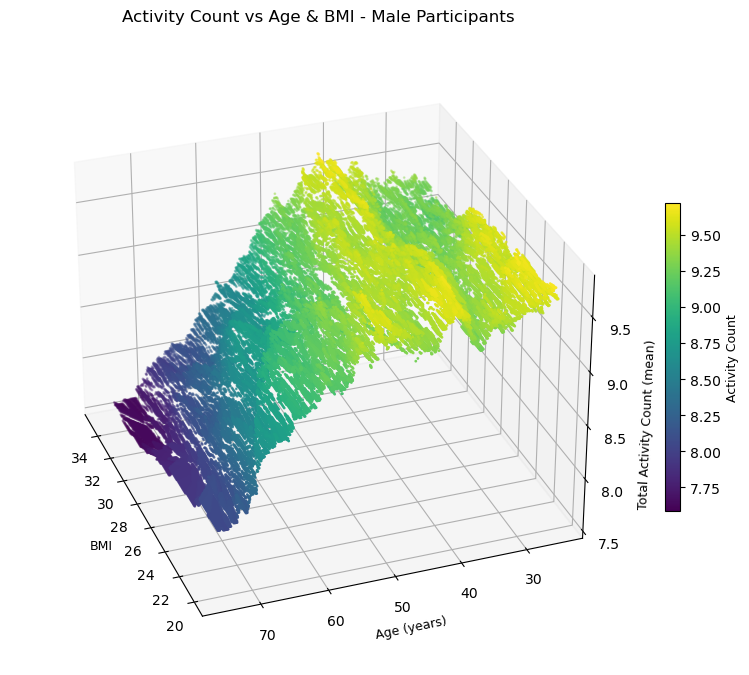

Plot saved as sarcopenia_gender_1_avg.png


In [7]:
# Create figure for 3D plot of conditional mean (BMI vs Age)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot with colormap
scatter = ax.scatter(
    df2.bmis,         # X-axis: BMI
    df2.ages,         # Y-axis: Age
    df2.glucoa,       # Z-axis: Conditional mean of activity count
    c=df2.glucoa,     # Color by activity count level
    cmap='viridis',   # Colormap
    s=1               # Point size
)

# Configure labels and visualization
ax.set_xlabel('BMI')
ax.set_ylabel('Age (years)')
ax.set_zlabel('Total Activity Count (mean)')
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Activity Count', shrink=0.5)

# Add title
ax.set_title('Activity Count vs Age & BMI - Male Participants', pad=20)

# Save figure
plt.savefig('sarcopenia_gender_1_avg.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()

print('Plot saved as sarcopenia_gender_1_avg.png')

### Plot 2: Standard Deviation of Total Activity Count

This 3D plot represents the **conditional standard deviation** of total activity count (square root of variance).

**Expected Interpretation**:
- **Age** may influence variability (older adults may show more heterogeneous activity patterns)
- **BMI** may affect consistency of activity levels
- Higher variance indicates less predictable activity patterns
- Lower variance suggests more consistent activity behaviors

**Key Finding**: This reveals which age/BMI combinations show the most variability in physical activity, which may relate to health status heterogeneity.

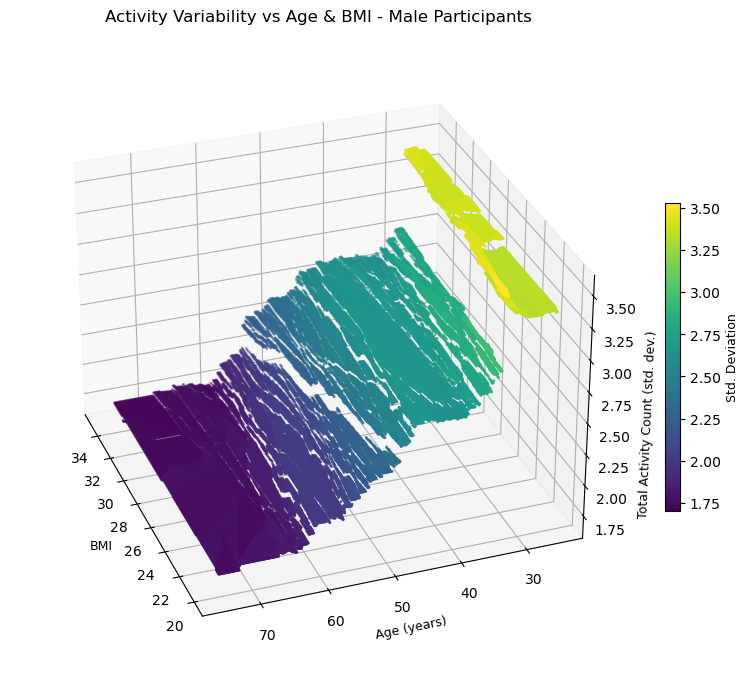

Plot saved as sarcopenia_gender_1_var.png


In [8]:
# Create figure for 3D plot of conditional variance (BMI vs Age)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Calculate standard deviation (square root of variance)
dev = np.sqrt(df2.glucov)

# 3D scatter plot with colormap
scatter = ax.scatter(
    df2.bmis,         # X-axis: BMI
    df2.ages,         # Y-axis: Age
    dev,              # Z-axis: Standard deviation of activity count
    c=dev,            # Color by standard deviation
    cmap='viridis',   # Colormap
    s=1               # Point size
)

# Configure labels and visualization
ax.set_xlabel('BMI')
ax.set_ylabel('Age (years)')
ax.set_zlabel('Total Activity Count (std. dev.)')
ax.grid(True)
ax.set_facecolor('white')  # White background
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Std. Deviation', shrink=0.5)

# Add title
ax.set_title('Activity Variability vs Age & BMI - Male Participants', pad=20)

# Save figure
plt.savefig('sarcopenia_gender_1_var.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()

print('Plot saved as sarcopenia_gender_1_var.png')